# **Import Libraries and Data**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# !pip install -U gensim

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
from collections import Counter
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk
import spacy
#from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Retail AI Solution/Datasets/Recommendation/Content Based/handm.csv')

In [5]:
df.head(2)

,Unnamed: 0,productId,productName,brandName,url,price,stockState,comingSoon,colorName,isOnline,colors,colorShades,newArrival,mainCatCode,details,materials
0,0,834333001,Derby Shoes,H&M,https://www2.hm.com/en_us/productpage.0834333001.html,49.99,Available,False,Black,True,272628,Charcoal,False,men_shoes_dressed,"Derby shoes with open lacing at front. Canvas lining and insoles. Heel height 1 in.\nArt. No.:0834333001\nHeel Height:\nLow heel\nFootwear type:\nDerby Shoes\nDescription:\nBlack, Solid-color\nImported:\nYes","COMPOSITION\nSole:Thermoplastic rubber 100%\nUpper:Polyurethane 100%\nLining and insole:Cotton 100% , ADDITIONAL MATERIAL INFORMATION\nThe total weight of this product contains:\n37% Recycled thermoplastic rubber\n1% Recycled cotton\nWe exclude the weight of minor components such as, but not exclusively: threads, buttons, zippers, embellishments and prints.\nThe total weight of the product is calculated by adding the weight of all layers and main components together. Based on that, we calculate how much of that weight is made out by each material. For sets and multipacks, all pieces are counted together as one product in calculations. , We exclude the weight of minor components such as, but not exclusively: threads, buttons, zippers, embellishments and prints.\nThe total weight of the product is calculated by adding the weight of all layers and main components together. Based on that, we calculate how much of that weight is made out by each material. For sets and multipacks, all pieces are counted together as one product in calculations. , Material:\nCanvas , MATERIALS IN THIS PRODUCT EXPLAINED\nCotton\nCotton is a soft and versatile natural fiber harvested from the cotton plant.\nPolyurethane\nPolyurethane (PU) is a synthetic material made from oil (a fossil resource).\nRecycled cotton\nRecycled cotton is cotton made from textile waste in production or from end-of-life textile waste. The waste is mechanically recycled and spun into new yarn.\nRecycled thermoplastic rubber\nRecycled thermoplastic rubber (TPR) is a synthetic rubber made from a type of polymer (a fossil resource). It has the characteristics of both rubber and plastic. Recycled TPR is made from plastic waste.\nThermoplastic rubber\nThermoplastic rubber (TPR) is a synthetic rubber made from a type of polymer (a fossil resource). It has the characteristics of both rubber and plastic. , Cotton\nCotton is a soft and versatile natural fiber harvested from the cotton plant. , Polyurethane\nPolyurethane (PU) is a synthetic material made from oil (a fossil resource). , Recycled cotton\nRecycled cotton is cotton made from textile waste in production or from end-of-life textile waste. The waste is mechanically recycled and spun into new yarn. , Recycled thermoplastic rubber\nRecycled thermoplastic rubber (TPR) is a synthetic rubber made from a type of polymer (a fossil resource). It has the characteristics of both rubber and plastic. Recycled TPR is made from plastic waste. , Thermoplastic rubber\nThermoplastic rubber (TPR) is a synthetic rubber made from a type of polymer (a fossil resource). It has the characteristics of both rubber and plastic."
1,1,1258600003,Pile-Lined Slippers,H&M,https://www2.hm.com/en_us/productpage.1258600003.html,24.99,Available,False,Black,True,272628,Charcoal,False,men_shoes_slippers,"Slippers in napped fabric. Decorative seam at top, fluted soles, and lining in soft pile. Sole thickness 3/4 in.\nArt. No.:1258600003\nHeel Height:\nNo heel\nDescription:\nBlack, Solid-color\nImported:\nYes","COMPOSITION\nLining:Polyester 100%\nUpper:Polyurethane 100%\nSole:Ethylene Vinyl Acetate 100% , ADDITIONAL MATERIAL INFORMATION\nThe total weight of this product contains:\n26% Recycled polyester\n11% Recycled ethylene-vinyl acetate\nWe exclude the weight of minor components such as, but not exclusively: threads, buttons, zippers, embellishments and prints.\nThe total weight of the product is calculated by adding the weight of all layers and main

In [6]:
df.shape

(9677, 16)

In [7]:
df.columns

Index(['Unnamed: 0', 'productId', 'productName', 'brandName', 'url', 'price',
       'stockState', 'comingSoon', 'colorName', 'isOnline', 'colors',
       'colorShades', 'newArrival', 'mainCatCode', 'details', 'materials'],
      dtype='object')

In [8]:
# Check for duplicates in the 'productid' column
df['productId'].duplicated().sum()

2006

In [9]:
new_df = df.drop_duplicates(subset='productId', keep='first')
new_df['productId'].duplicated().sum()

0

In [10]:
new_df.reset_index(drop=True, inplace=True)

In [11]:
new_df.columns

Index(['Unnamed: 0', 'productId', 'productName', 'brandName', 'url', 'price',
       'stockState', 'comingSoon', 'colorName', 'isOnline', 'colors',
       'colorShades', 'newArrival', 'mainCatCode', 'details', 'materials'],
      dtype='object')

In [12]:
# Product Name, Color, Materials

new_df = new_df[['productName', 'brandName', 'url', 'price', 'stockState', 'comingSoon', 'isOnline', 'newArrival', 'colorName', 'materials']]
new_df.head(3)

,productName,brandName,url,price,stockState,comingSoon,isOnline,newArrival,colorName,materials
0,Derby Shoes,H&M,https://www2.hm.com/en_us/productpage.0834333001.html,49.99,Available,False,True,False,Black,"COMPOSITION\nSole:Thermoplastic rubber 100%\nUpper:Polyurethane 100%\nLining and insole:Cotton 100% , ADDITIONAL MATERIAL INFORMATION\nThe total weight of this product contains:\n37% Recycled thermoplastic rubber\n1% Recycled cotton\nWe exclude the weight of minor components such as, but not exclusively: threads, buttons, zippers, embellishments and prints.\nThe total weight of the product is calculated by adding the weight of all layers and main components together. Based on that, we calculate how much of that weight is made out by each material. For sets and multipacks, all pieces are counted together as one product in calculations. , We exclude the weight of minor components such as, but not exclusively: threads, buttons, zippers, embellishments and prints.\nThe total weight of the product is calculated by adding the weight of all layers and main components together. Based on that, we calculate how much of that weight is made out by each material. For sets and multipacks, all pieces are counted together as one product in calculations. , Material:\nCanvas , MATERIALS IN THIS PRODUCT EXPLAINED\nCotton\nCotton is a soft and versatile natural fiber harvested from the cotton plant.\nPolyurethane\nPolyurethane (PU) is a synthetic material made from oil (a fossil resource).\nRecycled cotton\nRecycled cotton is cotton made from textile waste in production or from end-of-life textile waste. The waste is mechanically recycled and spun into new yarn.\nRecycled thermoplastic rubber\nRecycled thermoplastic rubber (TPR) is a synthetic rubber made from a type of polymer (a fossil resource). It has the characteristics of both rubber and plastic. Recycled TPR is made from plastic waste.\nThermoplastic rubber\nThermoplastic rubber (TPR) is a synthetic rubber made from a type of polymer (a fossil resource). It has the characteristics of both rubber and plastic. , Cotton\nCotton is a soft and versatile natural fiber harvested from the cotton plant. , Polyurethane\nPolyurethane (PU) is a synthetic material made from oil (a fossil resource). , Recycled cotton\nRecycled cotton is cotton made from textile waste in production or from end-of-life textile waste. The waste is mechanically recycled and spun into new yarn. , Recycled thermoplastic rubber\nRecycled thermoplastic rubber (TPR) is a synthetic rubber made from a type of polymer (a fossil resource). It has the characteristics of both rubber and plastic. Recycled TPR is made from plastic waste. , Thermoplastic rubber\nThermoplastic rubber (TPR) is a synthetic rubber made from a type of polymer (a fossil resource). It has the characteristics of both rubber and plastic."
1,Pile-Lined Slippers,H&M,https://www2.hm.com/en_us/productpage.1258600003.html,24.99,Available,False,True,False,Black,"COMPOSITION\nLining:Polyester 100%\nUpper:Polyurethane 100%\nSole:Ethylene Vinyl Acetate 100% , ADDITIONAL MATERIAL INFORMATION\nThe total weight of this product contains:\n26% Recycled polyester\n11% Recycled ethylene-vinyl acetate\nWe exclude the weight of minor components such as, but not exclusively: threads, buttons, zippers, embellishments and prints.\nThe total weight of the product is calculated by adding the weight of all layers and main components together. Based on that, we calculate how much of that weight is made out by each material. For sets and multipacks, all pieces are counted together as one product in calculations. , We exclude the weight of minor components such as, but not exclusively: threads, buttons, zippers, embellishments and prints.\nThe total weight of the product is calculated by adding the weight of all layers and main components together. Based on that, we calculate how much of that weight is made out by each material. For sets and multipacks, all pieces are counted together a

In [13]:
new_df.isnull().sum()

,0
productName,0
brandName,0
url,0
price,0
stockState,0
comingSoon,0
isOnline,0
newArrival,0
colorName,0
materials,122


In [14]:
new_df = new_df[new_df['materials'].notna()].copy()
new_df.isnull().sum()

,0
productName,0
brandName,0
url,0
price,0
stockState,0
comingSoon,0
isOnline,0
newArrival,0
colorName,0
materials,0


In [15]:
new_df.shape

(7549, 10)

In [16]:
new_df.reset_index(drop=True, inplace=True)

In [17]:
new_df.shape

(7549, 10)

In [18]:
# Clean the materials texts
def clean_text(text):
  text = text.lower()
  # Extract material names and percentages (e.g., "cotton 100%", "recycled thermoplastic rubber 37%")
  material_pattern = r'(\w+(?:\s+\w+)*)\s*:\s*([\w\s]+)\s+(\d+%|\d+\.\d+%)(?=\s|$|,|\n)'
  material_matches = re.findall(material_pattern, text)

  # Extract standalone material names (e.g., "Canvas")
  standalone_material_pattern = r'material:\s*(\w+(?:\s+\w+)*)(?=\s|$|,|\n)'
  standalone_materials = re.findall(standalone_material_pattern, text)

  # Combine materials with percentages and standalone materials
  materials = []
  for match in material_matches:
    # match[0] is the component (e.g., "Sole", "Upper"), match[1] is the material, match[2] is the percentage
    materials.append(f"{match[1]} {match[2]}".strip())
  materials.extend(standalone_materials)  # Add standalone materials like "Canvas"

  # Join materials into a single string
  cleaned_text = ' '.join(materials)

  # Further clean the text
  cleaned_text = re.sub(r'[^\w\s%]', '', cleaned_text)  # Remove punctuation except %
  cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()  # Remove extra spaces
  return cleaned_text

new_df['materials'] = new_df['materials'].apply(clean_text)
print(new_df['materials'][0])

thermoplastic rubber 100% polyurethane 100% cotton 100% canvas


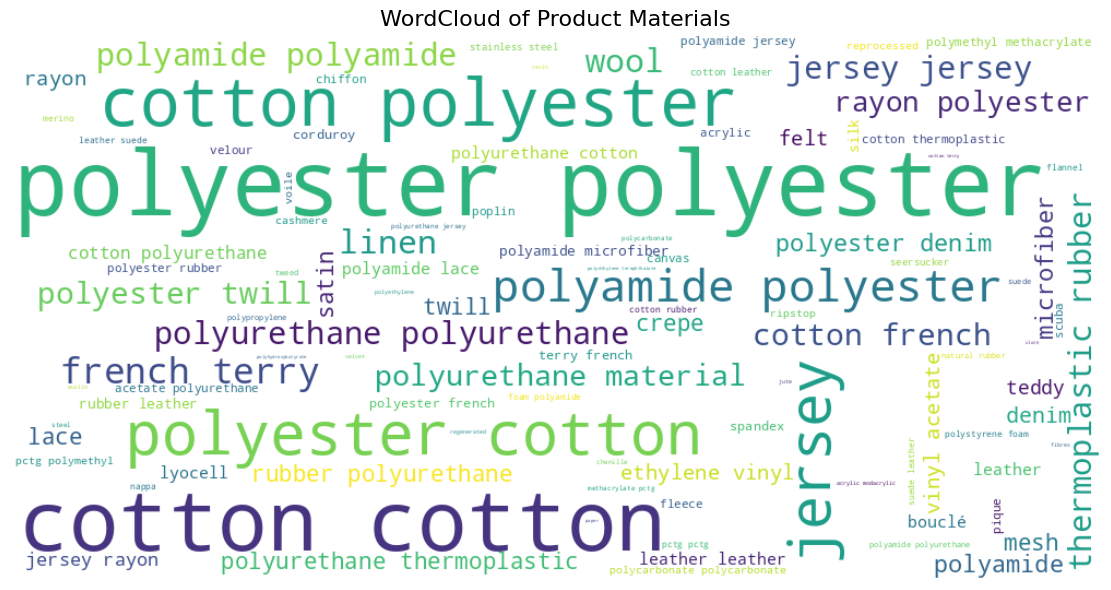

In [19]:
all_words = ' '.join(new_df['materials']).split()
wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(' '.join(all_words))
plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud of Product Materials', fontsize=16)
plt.tight_layout()
plt.show()

In [20]:
# new_df["productName"] = new_df["productName"].apply(lambda x: x.replace(" ", ""))
# new_df["colorName"] = new_df["colorName"].apply(lambda x: x.replace(" ", ""))
# new_df["materials"] = new_df["materials"].apply(lambda x: x.replace(" ", ""))

In [21]:
new_df.head(2)

,productName,brandName,url,price,stockState,comingSoon,isOnline,newArrival,colorName,materials
0,Derby Shoes,H&M,https://www2.hm.com/en_us/productpage.0834333001.html,49.99,Available,False,True,False,Black,thermoplastic rubber 100% polyurethane 100% cotton 100% canvas
1,Pile-Lined Slippers,H&M,https://www2.hm.com/en_us/productpage.1258600003.html,24.99,Available,False,True,False,Black,polyester 100% polyurethane 100% ethylene vinyl acetate 100% polyurethane material


In [22]:
new_df.columns

Index(['productName', 'brandName', 'url', 'price', 'stockState', 'comingSoon',
       'isOnline', 'newArrival', 'colorName', 'materials'],
      dtype='object')

In [23]:
new_df['color'] = new_df['colorName']

In [24]:
# Combine attributes into a space-separated tags column
new_df['tags'] =  new_df['colorName'].str.lower() + ' ' + new_df['colorName'].str.lower() + ' ' + new_df['materials'].str.lower()

# Now drop the original columns
new_df = new_df.drop(columns=['colorName', 'materials'])

# View first few rows to check
new_df.head()

,productName,brandName,url,price,stockState,comingSoon,isOnline,newArrival,color,tags
0,Derby Shoes,H&M,https://www2.hm.com/en_us/productpage.0834333001.html,49.99,Available,False,True,False,Black,black black thermoplastic rubber 100% polyurethane 100% cotton 100% canvas
1,Pile-Lined Slippers,H&M,https://www2.hm.com/en_us/productpage.1258600003.html,24.99,Available,False,True,False,Black,black black polyester 100% polyurethane 100% ethylene vinyl acetate 100% polyurethane material
2,Derby Shoes,H&M,https://www2.hm.com/en_us/productpage.1036812001.html,56.99,Available,False,True,False,Black,black black cotton 100% polyester 100% thermoplastic rubber 100% canvas
3,Fleece-lined Slippers,H&M,https://www2.hm.com/en_us/productpage.1112924002.html,29.99,Available,False,True,False,Dark blue,dark blue dark blue polyester 100% polyester 100% ethylene vinyl acetate 100%
4,Sneakers,H&M,https://www2.hm.com/en_us/productpage.1119476020.html,29.99,Available,False,True,False,White,white white polyester 100% polyurethane 100% rubber 100% polyurethane material


In [25]:
new_df["tags"][0]

'black black thermoplastic rubber 100% polyurethane 100% cotton 100% canvas'

In [26]:
# Strip extra spaces afterwards
new_df['tags'] = new_df['tags'].str.split().str.join(' ')

# Calculate the length of each entry in the 'tags' column
tag_lengths = new_df['tags'].str.len()

# Compute the minimum, mean, median, and maximum lengths
min_length = tag_lengths.min()
mean_length = tag_lengths.mean()
median_length = tag_lengths.median()
max_length = tag_lengths.max()

# Print the results
print(f"Minimum length of tags: {min_length}")
print(f"Mean length of tags: {mean_length:.2f}")
print(f"Median length of tags: {median_length}")
print(f"Maximum length of tags: {max_length}")

Minimum length of tags: 7
Mean length of tags: 37.90
Median length of tags: 37.0
Maximum length of tags: 156


In [27]:
new_df.tail()

,productName,brandName,url,price,stockState,comingSoon,isOnline,newArrival,color,tags
7544,Slim Straight High Jeans,H&M,https://www2.hm.com/en_us/productpage.1199187014.html,34.99,Available,False,True,False,Beige,beige beige cotton 99% polyester 65% denim
7545,Bootcut High Jeans,H&M,https://www2.hm.com/en_us/productpage.1198343002.html,39.99,Available,False,True,False,Light denim blue,light denim blue light denim blue cotton 99% polyester 65% cotton
7546,Lace Push-up Bra,H&M,https://www2.hm.com/en_us/productpage.1232588003.html,17.99,Available,False,True,False,Powder pink,powder pink powder pink polyamide 88% polyester 100% polyamide 83% lace
7547,2-pack Padded Soft-cup Cotton Bras,H&M,https://www2.hm.com/en_us/productpage.1208310002.html,24.99,Available,False,True,False,Beige/black,beige/black beige/black cotton 95% polyester 100% jersey
7548,Padded Balconette Bikini Top,H&M,https://www2.hm.com/en_us/productpage.1227825002.html,19.99,Available,False,True,False,Brown,brown brown polyester 93% polyester 89% polyamide 100%


# **Vectorization**

In [ ]:
# # Prepare data for Word2Vec
# sentences = [row.split() for row in new_df['tags']]
# word2vec_model = Word2Vec(sentences, vector_size=160, window=5, min_count=1, workers=4)

In [ ]:
# # Function to get average Word2Vec vector for a sentence
# def get_avg_word2vec(tags):
#     words = tags.split()
#     vec = np.zeros(300)
#     count = 0
#     for word in words:
#         if word in word2vec_model.wv:
#             vec += word2vec_model.wv[word]
#             count += 1
#     if count > 0:
#         vec /= count
#     return vec

In [ ]:
# # Create vectors
# vectors = np.array([get_avg_word2vec(tags) for tags in new_df['tags']])
# vectors[0]

In [28]:
# Vectorization using TF-IDF
tfidf = TfidfVectorizer(max_features=160, stop_words='english')
vectors = tfidf.fit_transform(new_df['tags']).toarray()

# **Cosine Similarity**

In [29]:
# Calculate cosine similarity
similarity = cosine_similarity(vectors)

In [30]:
similarity[0]

array([1.        , 0.43450424, 0.93943829, ..., 0.05820171, 0.28134702,
       0.08284846])

In [31]:
new_df.columns

Index(['productName', 'brandName', 'url', 'price', 'stockState', 'comingSoon',
       'isOnline', 'newArrival', 'color', 'tags'],
      dtype='object')

In [32]:
# Recommendation function
def recommend(cloth):
  try:
    cloth_index = new_df[new_df['productName'] == cloth].index[0]
    distances = similarity[cloth_index]
    cloth_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:10]  # Get top 10 to filter later

    # Filter out recommendations with the same product name
    recommended = []
    for i in cloth_list:
      if new_df.iloc[i[0]]['productName'] != cloth:
        recommended.append(i)
      if len(recommended) >= 5:  # Stop when we have 5 valid recommendations
        break

    # Print recommendations
    if not recommended:
      print("No recommendations found with different product names.")
      return

    for i in recommended:
      print(f"Product: {new_df.iloc[i[0]]['productName']}")
      print(f"Brand: {new_df.iloc[i[0]]['brandName']}")
      print(f"Brand: {new_df.iloc[i[0]]['color']}")
      print(f"Price: {new_df.iloc[i[0]]['price']}")
      print(f"Availability: {new_df.iloc[i[0]]['stockState']}")
      print(f"Online Availability: {new_df.iloc[i[0]]['isOnline']}")
      print(f"New Product: {new_df.iloc[i[0]]['newArrival']}")
      print(f"Link: {new_df.iloc[i[0]]['url']}")
      print(f"Similarity Score: {i[1]:.4f}")
      print("\n")

  except IndexError:
    print(f"Product '{cloth}' not found in the dataset.")
    return

  return

In [33]:
print(new_df['productName'][0:5])

0              Derby Shoes
1      Pile-Lined Slippers
2              Derby Shoes
3    Fleece-lined Slippers
4                 Sneakers
Name: productName, dtype: object


In [34]:
recommend('Derby Shoes')

Product: Canvas Toiletry Bag
Brand: H&M
Brand: Black
Price: 19.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1113325001.html
Similarity Score: 0.8689


Product: Canvas Espadrilles
Brand: H&M
Brand: Black
Price: 26.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1215175001.html
Similarity Score: 0.8618


Product: Chelsea Boots
Brand: H&M
Brand: Black
Price: 59.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1072672004.html
Similarity Score: 0.8436


Product: Loafers
Brand: H&M
Brand: Black
Price: 59.99
Availability: Available
Online Availability: True
New Product: True
Link: https://www2.hm.com/en_us/productpage.1250118001.html
Similarity Score: 0.8436


Product: Lace-Up Boots
Brand: H&M
Brand: Black
Price: 74.99
Availability: Available
Online Availability: True
New Product: True
Link

In [35]:
recommend('Pile-Lined Slippers')

Product: Chunky Derby Shoes
Brand: H&M
Brand: Black
Price: 64.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1072732001.html
Similarity Score: 0.9812


Product: Chunky Platform Sandals
Brand: H&M
Brand: Black
Price: 39.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1224749002.html
Similarity Score: 0.9400


Product: Sandals
Brand: H&M
Brand: Black
Price: 34.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1223178001.html
Similarity Score: 0.9400


Product: Chelsea Boots
Brand: H&M
Brand: Black
Price: 59.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1250116001.html
Similarity Score: 0.9242


Product: Lace-Up Boots
Brand: H&M
Brand: Black
Price: 74.99
Availability: Available
Online Availability: True
New Product: True

In [36]:
recommend('Teddy Fleece Slippers')

Product: Warm-lined Slippers
Brand: H&M
Brand: Dark brown
Price: 19.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1003418010.html
Similarity Score: 0.9296


Product: Warm-lined Boots
Brand: H&M
Brand: Dark brown
Price: 24.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1172015003.html
Similarity Score: 0.9296


Product: Intertwined-strap Sandals
Brand: H&M
Brand: Dark brown
Price: 29.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1224746003.html
Similarity Score: 0.9043


Product: Chunky Derby Shoes
Brand: H&M
Brand: Dark brown
Price: 54.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1227974002.html
Similarity Score: 0.8711


Product: Warm-lined Slippers
Brand: H&M
Brand: Brown
Price: 19.99
Availability: Available


In [37]:
recommend('Chunky Derby Shoesi')

Product 'Chunky Derby Shoesi' not found in the dataset.


In [38]:
recommend('Chunky Derby Shoes')

Product: Chelsea Boots
Brand: H&M
Brand: Black
Price: 59.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1250116001.html
Similarity Score: 0.9699


Product: Lace-Up Boots
Brand: H&M
Brand: Black
Price: 74.99
Availability: Available
Online Availability: True
New Product: True
Link: https://www2.hm.com/en_us/productpage.1250009001.html
Similarity Score: 0.9699


Product: Chunky Platform Sandals
Brand: H&M
Brand: Black
Price: 39.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1224749002.html
Similarity Score: 0.9544


Product: Sandals
Brand: H&M
Brand: Black
Price: 34.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1223178001.html
Similarity Score: 0.9544


Product: Trekking Boots
Brand: H&M
Brand: Black
Price: 91.99
Availability: Available
Online Availability: True
New Product: False
Lin

In [39]:
recommend('Sneakers')

Product: Faux Leather Sneakers
Brand: H&M
Brand: White
Price: 36.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1002745005.html
Similarity Score: 1.0000


Product: Small Crossbody Bag
Brand: H&M
Brand: White
Price: 17.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1238251006.html
Similarity Score: 0.9323


Product: Shoulder Bag
Brand: H&M
Brand: White
Price: 19.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1188402004.html
Similarity Score: 0.9036




In [40]:
recommend('Walking Boots')

Product: Fluffy Slippers
Brand: H&M
Brand: Beige
Price: 24.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1249147002.html
Similarity Score: 0.9294


Product: Chunky Chelsea Boots
Brand: H&M
Brand: Beige
Price: 49.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1239744002.html
Similarity Score: 0.9180


Product: Warm-lined Boots
Brand: H&M
Brand: Beige
Price: 59.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1193143005.html
Similarity Score: 0.9180


Product: Laced Padded Boots
Brand: H&M
Brand: Beige
Price: 59.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1198268004.html
Similarity Score: 0.8853


Product: Straw Shopper
Brand: H&M
Brand: Beige
Price: 29.99
Availability: Available
Online Availability: True
New Produ

In [41]:
recommend('Green Embroidered and Printed Handloom Viscose Ethnic Scarf')

Product 'Green Embroidered and Printed Handloom Viscose Ethnic Scarf' not found in the dataset.


# **Evaluation**

In [42]:
# Function to check if two items are relevant based on shared color or materials
def is_relevant(item1_tags, item2_tags, item1_color, item2_color):
  item1_materials = set(item1_tags.split())
  item2_materials = set(item2_tags.split())
  return item1_color == item2_color or len(item1_materials.intersection(item2_materials)) > 0

In [43]:
# Modified recommendation function to return indices and scores for evaluation
def get_recommendations(cloth, df, similarity, K=5):
  try:
    cloth = cloth.strip().lower()
    product_names = df['productName'].str.strip().str.lower()
    matching_indices = df[product_names == cloth].index
    if len(matching_indices) == 0:
      return []

    cloth_index = matching_indices[0]
    if cloth_index >= len(df):
      return []

    distances = similarity[cloth_index]
    cloth_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:10]

    recommended = []
    for i in cloth_list:
      if i[0] < len(df) and df.iloc[i[0]]['productName'].strip().lower() != cloth:
        recommended.append(i)
      if len(recommended) >= K:
        break
    return recommended
  except Exception:
    return []

In [44]:
# Function to compute Precision@K for a single product
def precision_at_k(cloth, df, similarity, K=5):
  recommended = get_recommendations(cloth, df, similarity, K)
  if not recommended:
    return 0.0

  input_product = df[df['productName'].str.strip().str.lower() == cloth.strip().lower()].iloc[0]
  input_tags = input_product['tags']
  input_color = input_product['color']

  relevant_count = 0
  for idx, _ in recommended:
    if idx < len(df):
      rec_product = df.iloc[idx]
      rec_tags = rec_product['tags']
      rec_color = rec_product['color']
      if is_relevant(input_tags, rec_tags, input_color, rec_color):
        relevant_count += 1

  return relevant_count / K

In [45]:
# Evaluate Precision@K across a sample of products
def evaluate_model(df, similarity, sample_size=100, K=5):
  sample_indices = np.random.choice(df.index, size=min(sample_size, len(df)), replace=False)
  precisions = []
  for idx in sample_indices:
    cloth = df.iloc[idx]['productName']
    precision = precision_at_k(cloth, df, similarity, K)
    precisions.append(precision)

  avg_precision = np.mean(precisions)
  return avg_precision

In [46]:
# Run evaluation
sample_size = new_df.shape[0]
K = 10
avg_precision = evaluate_model(new_df, similarity, sample_size, K)
print(f"Average Precision@{K}: {avg_precision:.4f}")

Average Precision@10: 0.8122
